<font color=red>**Danger zone:**</font> you'll be fine-tuning a model to generate positive, negative or even toxic reviews. We'll be doing this for fun, but this is also the technique for [review bombing](https://en.wikipedia.org/wiki/Review_bomb), bot farms on social media and other less than dignified stuff. It is ultimately your decision how you apply this knowledge, but before you choose, ask yourself: is this why you chose to learn ML?

---




# LLMs Alignment with Reinforcement Learning from human feedback (RLHF).

---

_based on the [original notebook](https://github.com/antndlcrx/oxford-llms-workshop/blob/main/materials/seminars/day_3/8_LLMs%20alignment%20with%20RLHF.ipynb) by Ilya Boytsov for the Oxford LLMs workshop_

---

Trong buổi thực hành này, chúng ta sẽ fine-tune một mô hình ngôn ngữ (language model) với reinforcement learning
để làm cho nó tạo ra các bài đánh giá tốt (hoặc xấu).

Để thực hiện RL-based fine-tuning, chúng ta sẽ sử dụng một thư viện mới (trong khóa học này) có tên là
[Transformer Reinforcement Learning (TRL)](https://huggingface.co/docs/trl).
TRL triển khai các thành phần reinforcement learning chính của RLHF:
reward modeling và fine-tuning với PPO (Proximal Policy Optimization).

![img](https://huggingface.co/datasets/trl-internal-testing/example-images/resolve/main/images/TRL-readme.png)

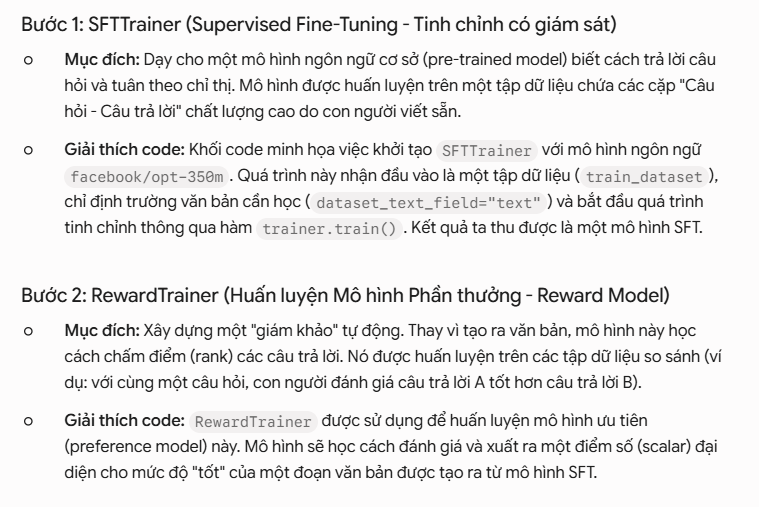

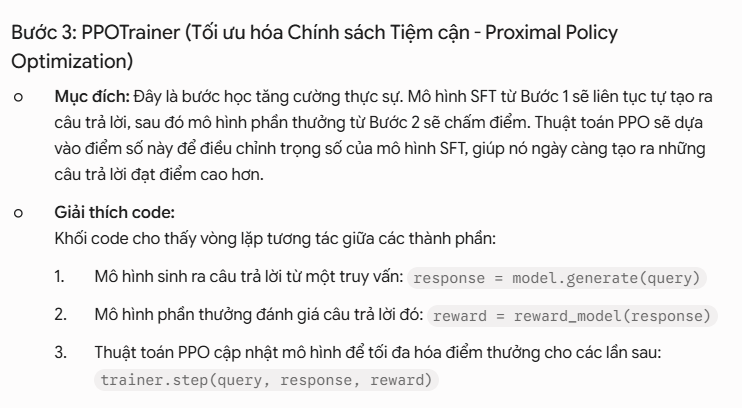

## 1. Cài đặt thư viện (Install Dependencies)

Chúng ta cài đặt các thư viện cần thiết:
- `trl`: thư viện Reinforcement Learning cho Transformers
- `transformers`: thư viện HuggingFace Transformers
- `datasets`: thư viện dataset của HuggingFace
- `peft`: thư viện Parameter-Efficient Fine-Tuning (LoRA, Prompt Tuning...)

In [ ]:
# Cài đặt thư viện phiên bản tương thích với bài tập
# SAU KHI CHẠY XONG CELL NÀY, BẮT BUỘC PHẢI RESTART KERNEL (Run → Restart Session)
# rồi chạy lại notebook từ đầu
!pip install trl==0.8.6 peft==0.11.1 --quiet

In [ ]:
# Cài đặt trl, transformers, datasets, peft và đặc biệt là accelerate
# LƯU Ý QUAN TRỌNG: Trên Kaggle, sau khi chạy cell này, bạn CẦN chọn "Restart Session" hoặc "Restart Kernel"
# để các thư viện mới được tải đúng cách, tránh bị nghẽn (hang) ở bước import trl.
%pip install -qU transformers datasets accelerate


---

### Tutorial: align the model to generate positive movie reviews

Để xem TRL hoạt động như thế nào, chúng ta sẽ sử dụng nó để align mô hình GPT2 trên dataset IMDB
để tạo ra các bài đánh giá phim tích cực (hoặc tiêu cực).
Thực ra, **bạn có quyền lựa chọn muốn đánh giá tích cực hay tiêu cực.**

Nhưng trước khi chọn, hãy xem mô hình baseline: một GPT-2 được fine-tune để tạo ra các bài đánh giá phim bất kỳ.

In [1]:
import torch
import transformers

# --- TỐI ƯU HÓA SONG SONG 2 GPU TRÊN KAGGLE ---
# Kaggle cung cấp 2 GPU T4 (15GB/16GB VRAM mỗi card).
# Chúng ta sẽ cấu hình: GPU 0 chạy Main Model (GPT-2) & PPO Trainer, GPU 1 chạy Reward Model (DistilBERT).
# Việc chia này giúp tận dụng tối đa sức mạnh của 2 GPU, tránh nghẽn cổ chai và tràn bộ nhớ (OOM).

if torch.cuda.device_count() >= 2:
    device_main = torch.device('cuda:0')
    device_reward = torch.device('cuda:1')
    print(f"Phát hiện {torch.cuda.device_count()} GPUs. Đang cấu hình tối ưu song song:\n")
    print(f" - GPU 0 ({torch.cuda.get_device_name(0)}) -> Main Model (GPT-2) & PPOTrainer")
    print(f" - GPU 1 ({torch.cuda.get_device_name(1)}) -> Reward Model (DistilBERT)")
elif torch.cuda.is_available():
    device_main = torch.device('cuda:0')
    device_reward = torch.device('cuda:0')
    print(f"Phát hiện 1 GPU ({torch.cuda.get_device_name(0)}). Tất cả model chạy trên GPU 0.")
else:
    device_main = torch.device('cpu')
    device_reward = torch.device('cpu')
    print("Chạy trên CPU (lưu ý: Tiến trình training sẽ rất chậm).")

# Load tokenizer và model GPT-2 đã fine-tune trên IMDB lên device_main (GPU 0)
main_tokenizer = transformers.AutoTokenizer.from_pretrained("lvwerra/gpt2-imdb")
main_model = transformers.AutoModelForCausalLM.from_pretrained("lvwerra/gpt2-imdb").to(device_main)


Phát hiện 2 GPUs. Đang cấu hình tối ưu song song:

 - GPU 0 (Tesla T4) -> Main Model (GPT-2) & PPOTrainer
 - GPU 1 (Tesla T4) -> Reward Model (DistilBERT)


config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

In [2]:
# --- THỬ SINH VĂN BẢN VỚI MODEL GỐC (BASELINE) ---
# Shape: input_ids = (batch_size=1, seq_len)

inputs = main_tokenizer("The movie", return_tensors='pt').to(device_main)
print(f"Input shape: {inputs['input_ids'].shape}")  # (1, 2) - 2 tokens: 'The' và ' movie'

# Sinh tiếp 50 token mới (max_new_tokens=50) với sampling (do_sample=True)
generated_ids = main_model.generate(**inputs, max_new_tokens=50, do_sample=True)
print(f"Generated shape: {generated_ids.shape}")  # (1, 52) - 2 tokens input + 50 tokens mới

print("\nGenerated text:", main_tokenizer.decode(generated_ids.flatten().cpu().numpy().tolist()))


Input shape: torch.Size([1, 2])
Generated shape: torch.Size([1, 36])

Generated text: The movie is truly magnificent in their own way - a brilliantly acted and extremely charming film, and highly entertaining to watch with your family and friends and even with the big screen.<|endoftext|>


Nếu bạn chạy cell này vài lần, bạn sẽ thấy mô hình sinh ra cả bài đánh giá tích cực, tiêu cực và trung tính
với một tỷ lệ nhất định. Điều chúng ta sắp làm là dạy mô hình sinh ra nhiều bài đánh giá tích cực (hoặc tiêu cực) hơn.

Tương tự như InstructGPT, chúng ta sẽ làm điều này qua 2 giai đoạn:

- **Train một reward model** để gán giá trị cao hơn cho các bài đánh giá tích cực (hoặc tiêu cực)
- **Fine-tune language model** để **tối đa hóa reward đó bằng [Proximal Policy Optimization (PPO)](https://openai.com/research/openai-baselines-ppo)**

---
## Stage 1: Train a Reward Model (1 điểm)

Đầu tiên, chúng ta sẽ train một mô hình kiểu BERT làm reward model.
Chúng ta sẽ tạo synthetic pairwise rankings để mô phỏng human rankings.

**Q:** Tại sao cần một reward model? Có thể dùng luôn một pre-trained sentiment classifier không?
**A:** Có, bạn hoàn toàn có thể - nhưng cách đó chỉ hiệu quả cho movie reviews.
Còn tutorial này sẽ dạy bạn cách làm RLHF cho bất kỳ mục tiêu nào.

> **Nếu bạn thực sự muốn tối đa hóa sentiment (hoặc 'label' khác) thay vì human preferences,
hãy train reward model như một classifier! (xem week5)**

reward models giống mô hình hồi quy để trả về 1 con số reward tuy nhiên

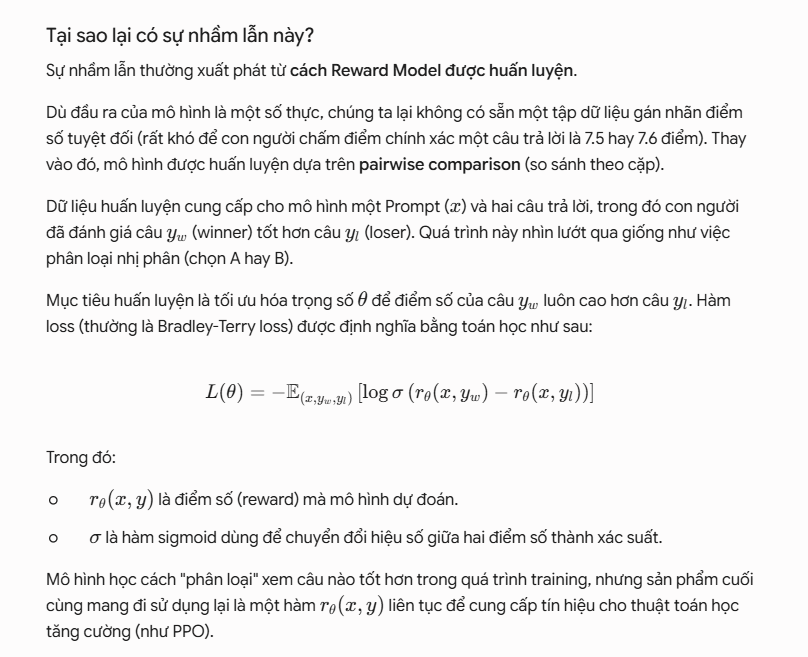

Dùng để train:

In [3]:
# # --- LOAD REWARD MODEL LÊN GPU 1 (device_reward) ---
# # Dùng DistilBERT làm reward model để phân loại review tích cực/tiêu cực.
# # SỬA LỖI: Cấu hình num_labels=1 để mô hình trả về một điểm số scalar duy nhất làm reward (theo yêu cầu của RewardTrainer mới).
# reward_model = transformers.AutoModelForSequenceClassification.from_pretrained(
#     "distilbert-base-cased", num_labels=1
# ).to(device_reward)
# reward_tokenizer = transformers.AutoTokenizer.from_pretrained("distilbert-base-cased")

# # SỬA LỖI: DistilBERT mặc định không có eos_token (bằng None). Chúng ta đặt eos_token = sep_token ('[SEP]')
# # để tránh lỗi TypeError: endswith first arg must be str hoặc a tuple of str, not NoneType khi chạy RewardTrainer.
# if reward_tokenizer.eos_token is None:
#     reward_tokenizer.eos_token = reward_tokenizer.sep_token

# print(f"Reward model device: {reward_model.device}")
# print(f"Reward model config: num_labels={reward_model.config.num_labels}")
# print(f"Reward tokenizer eos_token: {reward_tokenizer.eos_token}")


Dùng sau khi train, chỉ cần load lại tham số: 

In [ ]:
# Đường dẫn thực tế đến checkpoint của bạn trên Kaggle
checkpoint_path = "/kaggle/input/datasets/YourAccountName/results-trainingrewardmodels/reward_model/checkpoint-1000"

# Load model từ checkpoint đã train thay vì "distilbert-base-cased"
reward_model = transformers.AutoModelForSequenceClassification.from_pretrained(
    checkpoint_path, num_labels=1 # 1 label cho 2 giá trị nhị phân
).to(device_reward)

reward_tokenizer = transformers.AutoTokenizer.from_pretrained("distilbert-base-cased")

if reward_tokenizer.eos_token is None:
    reward_tokenizer.eos_token = reward_tokenizer.sep_token # sep stands for separate

print(f"Reward model loaded successfully from checkpoint: {checkpoint_path}")
print(f"Reward model device: {reward_model.device}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Reward model loaded successfully from checkpoint: /kaggle/input/datasets/ngamyduong1980/results-trainingrewardmodels/reward_model/checkpoint-1000
Reward model device: cuda:1


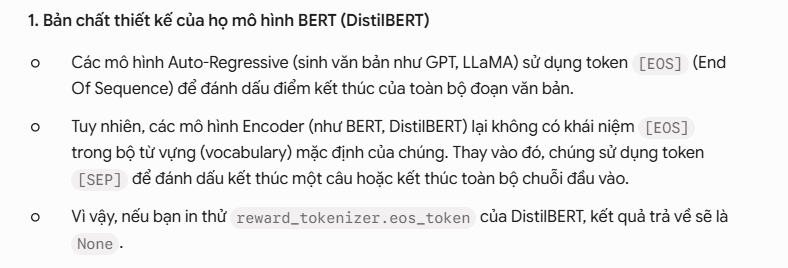

> **Lưu ý:** Reward model có tokenizer riêng, khác với main model.
Chúng không cần phải giống nhau cho RLHF fine-tuning.

In [5]:
import torch
import datasets
import random

def IMDBPairwiseDataset(imdb, tokenizer, accepted_label: int, num_pairs=50000):
    """
    Hàm tạo Pairwise Dataset tương thích với TRL RewardTrainer (bản mới yêu cầu 'chosen' và 'rejected' là chuỗi thô).
    TỐI ƯU HÓA:
      1. Sinh ngẫu nhiên {num_pairs} cặp so sánh chuỗi thô giúp tránh tràn bộ nhớ RAM (OOM).
      2. Trả về đối tượng datasets.Dataset có hai cột 'chosen' và 'rejected'.
      3. Việc tokenize sẽ được RewardTrainer xử lý tự động trong quá trình huấn luyện bằng tokenizer truyền vào.
    """
    random.seed(42)
    
    # Lọc các text theo nhãn
    raw_chosen = [row['text'] for row in imdb if row['label'] == accepted_label]
    raw_rejected = [row['text'] for row in imdb if row['label'] != accepted_label]
    
    assert raw_chosen, f"Không có text nào với label {accepted_label}"
    
    chosen_texts = []
    rejected_texts = []
    
    print(f"Đang tạo {num_pairs} cặp ngẫu nhiên (chosen vs rejected) dạng text thô...")
    for _ in range(num_pairs):
        c_idx = random.randint(0, len(raw_chosen) - 1) # dùng cách này thì có thể chọn lại câu trùng
        r_idx = random.randint(0, len(raw_rejected) - 1)# lấy ngẫu nhiên có hoàn lại
        
        chosen_texts.append(raw_chosen[c_idx])
        rejected_texts.append(raw_rejected[r_idx])

    # Lấy ngẫu nhiên không trùng lặp (lưu ý: num_pairs phải <= chiều dài của list)
        # chosen_texts = random.sample(raw_chosen, num_pairs)
        # rejected_texts = random.sample(raw_rejected, num_pairs)
        
    # Trả về đối tượng datasets.Dataset chứa các cột chuỗi thô
    return datasets.Dataset.from_dict({
        'chosen': chosen_texts,
        'rejected': rejected_texts
    })


### Chọn target label

Chúng ta chọn label mục tiêu:
- `TARGET_LABEL = 1`: positive reviews (đánh giá tích cực) - đây là lựa chọn của chúng ta
- `TARGET_LABEL = 0`: negative reviews (đánh giá tiêu cực)

Dataset IMDB có:
- label 0: negative (negative sentiment)
- label 1: positive (positive sentiment)

Chúng ta sẽ chọn **1 (positive)** để hướng mô hình sinh ra các bài đánh giá tích cực.

In [ ]:
# --- CHỌN TARGET LABEL ---
# Chọn 1 cho positive reviews (hoặc 0 cho negative reviews)
TARGET_LABEL = 1   # 1 = positive, 0 = negative

# Load IMDB dataset (chỉ dùng train split cho việc train reward model)
imdb = datasets.load_dataset("imdb", split='train') # chỉ yêu cầu thư viện tải tập huấn luyện trong dataset remote kéo về 
print(f"IMDB dataset size: {len(imdb)}")  # 25,000 samples
print(f"Sample 0 label: {imdb[0]['label']}, text[:100]: {imdb[0]['text'][:100]}...")

# Tạo pairwise dataset dạng chuỗi thô
reward_data = IMDBPairwiseDataset(imdb, reward_tokenizer, accepted_label=TARGET_LABEL)

# CẤU HÌNH CHO DỪNG SỚM (EARLY STOPPING): Chia tập dữ liệu thành 90% train và 10% eval
split_dataset = reward_data.train_test_split(test_size=0.1, seed=42)
hf_reward_data = split_dataset['train']
hf_eval_data = split_dataset['test']

# Kiểm tra thử 1 sample
sample = hf_reward_data[31337]
print('\nCHOSEN (100 ký tự đầu):', sample['chosen'][:100] + '...')
print('REJECTED (100 ký tự đầu):', sample['rejected'][:100] + '...')


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB dataset size: 25000
Sample 0 label: 0, text[:100]: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w...
Đang tạo 50000 cặp ngẫu nhiên (chosen vs rejected) dạng text thô...

CHOSEN (100 ký tự đầu): It is a tricky thing to play a queen. On the one hand, the actress has to be majestic and imperious,...
REJECTED (100 ký tự đầu): Can you say "All shock, no plot?" There were so many unexplored directions in this movie. There was ...


### RewardTrainer

Chúng ta sẽ sử dụng `trl.RewardTrainer` - một trường hợp đặc biệt của `transformers.Trainer`.
`RewardTrainer` huấn luyện mô hình với pairwise reward objective từ [InstructGPT paper](https://arxiv.org/pdf/2203.02155.pdf):

![img](https://i.imgur.com/2JzNAPs.png)

**Công thức loss:**
$$\text{loss}(\psi) = -\mathbb{E}_{(x, y_w, y_l) \sim D} \left[ \log \sigma(r_\psi(x, y_w) - r_\psi(x, y_l)) \right]$$

Trong đó:
- $x$: context (trong trường hợp movie reviews thì $x$ là rỗng)
- $y_w$: sample được ưa thích hơn (chosen)
- $y_l$: sample bị từ chối (rejected)
- $r_\psi$: reward model với parameters $\psi$
- $\sigma$: hàm sigmoid

Mô hình không xử lý cặp cùng nhau: nó xử lý chosen ($y_w$) và rejected ($y_l$) độc lập.
Để tối thiểu hóa loss này, reward model cần ghi điểm chosen sample cao hơn rejected sample.

In [7]:
import torch

print("GPU có sẵn không (CUDA available):", torch.cuda.is_available())

if torch.cuda.is_available():
    print("Tên GPU đang dùng:", torch.cuda.get_device_name(0))
    print("Số lượng GPU:", torch.cuda.device_count())
else:
    print("Môi trường hiện tại CHỈ đang dùng CPU!")

GPU có sẵn không (CUDA available): True
Tên GPU đang dùng: Tesla T4
Số lượng GPU: 2


In [8]:
# import trl
# from transformers import EarlyStoppingCallback

# # Tự động chọn fp16 dựa trên GPU khả dụng
# is_gpu_available = torch.cuda.is_available()

# # --- TỐI ƯU CẤU HÌNH TRAINING REWARD MODEL + EARLY STOPPING ---
# training_args = trl.RewardConfig(
#     output_dir="reward_model",
#     per_device_train_batch_size=32,        # TỐI ƯU: Tăng từ 2 lên 32 để tận dụng tối đa bộ nhớ GPU 16GB
#     gradient_accumulation_steps=2,         # TỐI ƯU: Giảm từ 32 xuống 2 để giảm số lần tích lũy gradient, tăng tốc huấn luyện cực lớn
#     learning_rate=1.41e-5,
#     max_steps=1_000,                       # Tổng số bước tối ưu hóa
#     max_length=512,                        # SỬA LỖI: Đặt max_length=512 để phù hợp với giới hạn của DistilBERT (tránh lỗi RuntimeError do độ dài vượt quá 512)
#     logging_steps=10,                      # Ghi log sau mỗi 10 steps (tránh in ra quá nhiều làm chậm notebook)
#     report_to="none",                      # Tắt gửi log lên Wandb/Tensorboard để tập trung in ra màn hình
#     gradient_checkpointing=True,           # Tiết kiệm bộ nhớ GPU khi train
#     gradient_checkpointing_kwargs={"use_reentrant": False},
#     fp16=is_gpu_available,                 # Tự động bật fp16 (mixed precision) giúp tính toán nhanh hơn 2-3 lần trên GPU
    
#     # CẤU HÌNH ĐÁNH GIÁ ĐỂ DỪNG SỚM:
#     eval_strategy="steps",                 # Đánh giá loss trên tập validation theo số bước
#     eval_steps=50,                         # Đánh giá sau mỗi 50 bước huấn luyện
#     save_steps=50,                         # Lưu checkpoint tương ứng mỗi 50 bước để có thể khôi phục model tốt nhất
#     save_total_limit=1,                    # Chỉ giữ lại checkpoint tốt nhất để tránh tràn ổ đĩa Kaggle
#     load_best_model_at_end=True,           # Tải mô hình tốt nhất (loss thấp nhất) sau khi dừng huấn luyện
#     metric_for_best_model="eval_loss",     # Lấy eval_loss làm tiêu chí chọn mô hình tốt nhất
#     greater_is_better=False                # Điểm loss càng nhỏ càng tốt
# )

# print("Đang khởi tạo Trainer...")
# # --- KHỞI TẠO REWARD TRAINER VỚI CALLBACK DỪNG SỚM ---
# trainer = trl.RewardTrainer(
#     model=reward_model,
#     args=training_args,
#     processing_class=reward_tokenizer,
#     train_dataset=hf_reward_data,          # Tập train (90%)
#     eval_dataset=hf_eval_data,             # Tập eval (10%)
#     peft_config=None,
#     callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Dừng sớm nếu eval_loss không giảm sau 3 lần eval liên tiếp (150 steps)
# )

# print("Bắt đầu tiến trình Training...")
# # --- TIẾN HÀNH TRAINING ---
# trainer.train()
# print("Hoàn thành Training!")


kết quả sau train: 

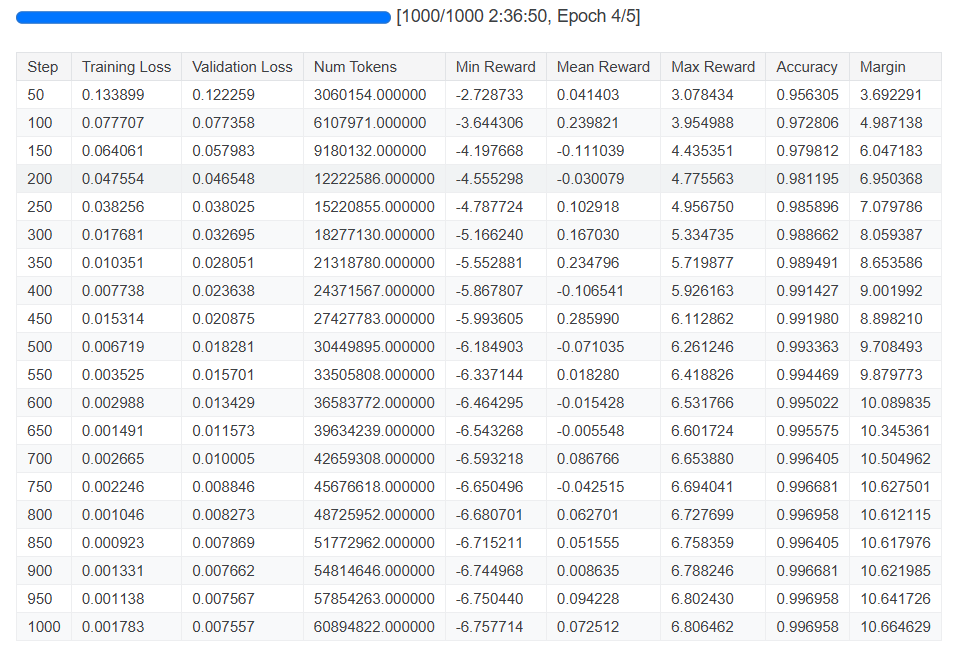

In [9]:
# --- TẮT GRADIENT CHECKPOINTING & CHUYỂN SANG EVAL MODE ---
# Sau khi train xong, tắt gradient checkpointing để inference nhanh hơn
reward_model.gradient_checkpointing_disable()
reward_model.to(device_reward)  # <--- THÊM DÒNG NÀY ĐỂ ĐƯA MODEL VỀ LẠI GPU 1 (device_reward)
reward_model.eval()  # Chuyển sang evaluation mode (tắt dropout, batch norm...)
print("Reward model ready for evaluation!")


Reward model ready for evaluation!


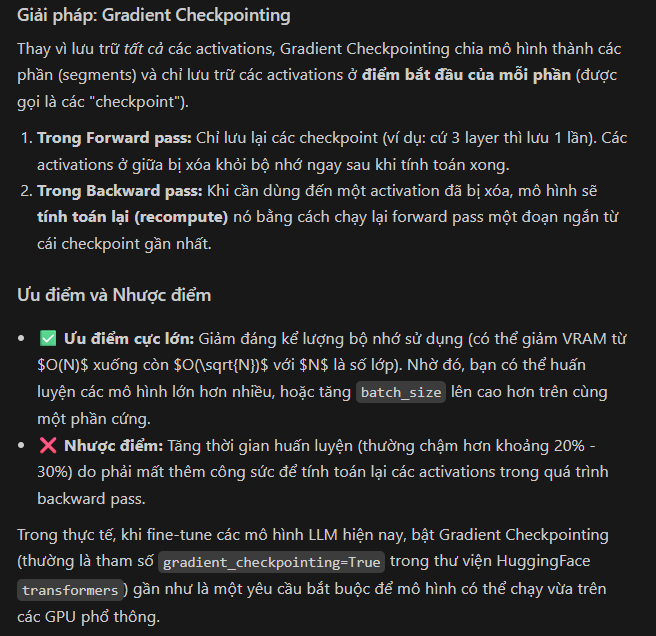

---
### Sanity-check the reward model (1 điểm)

Hãy kiểm tra reward model của chúng ta hoạt động như thế nào.

**Nhiệm vụ của bạn:** Đo xem reward model có thể xếp hạng đúng một cặp (chosen, rejected) reviews bao nhiêu phần trăm.
Hãy đo riêng trên:
- **Train data** (`imdb` - split 'train')
- **Test data** (load từ `imdb` với split='test')

Cách tính accuracy:
- Với mỗi cặp (chosen, rejected), reward model tính reward cho mỗi câu
- Nếu reward(chosen) > reward(rejected) → đúng (correct)
- Accuracy = số cặp đúng / tổng số cặp

In [10]:
# --- KIỂM TRA NHANH REWARD MODEL TRÊN VÀI MẪU ---
for sample_index in [45, 16000]:
    print('TEXT:', imdb[sample_index]['text'][:200] + "...")
    
    # Tokenize và đưa lên device_reward (GPU 1)
    inputs = reward_tokenizer(
        imdb[sample_index]['text'], truncation=True, return_tensors='pt'
    ).to(device_reward)
    print(f"  Input shape: {inputs['input_ids'].shape}")  # (1, seq_len)
    
    # Tính reward (không tính gradient)
    with torch.no_grad():
        reward = reward_model(**inputs).logits[0, 0].item()  # logits[0, 0] = reward score
        print("  REWARD:", reward)
    
    print('  LABEL:', imdb[sample_index]['label'])
    print()


TEXT: This movie sucked. It really was a waste of my life. The acting was atrocious, the plot completely implausible. Long, long story short, these people get "terrorized" by this pathetic "crazed killer", ...
  Input shape: torch.Size([1, 177])
  REWARD: -6.4346113204956055
  LABEL: 0

TEXT: Good: Engaging cinematic firefights, great presentation, vehicles are actually fun to drive, fairly appealing multiplayer, faithful to the movie, and the list goes on.<br /><br />Bad: Main missions ar...
  Input shape: torch.Size([1, 265])
  REWARD: 6.164135456085205
  LABEL: 1



In [ ]:
# --- ĐÁNH GIÁ REWARD MODEL TRÊN TEST SET ---
# Load IMDB test set
imdb_test = datasets.load_dataset("imdb", split='test')
print(f"IMDB test set size: {len(imdb_test)}")  # 25,000 samples

# Tạo pairwise dataset cho test set để đánh giá
n_chosen_test = 200    # Lấy 200 chosen texts
n_rejected_test = 200  # Lấy 200 rejected texts

# Lọc chosen và rejected từ test set
test_chosen = [row['text'] for row in imdb_test if row['label'] == TARGET_LABEL][:n_chosen_test]
test_rejected = [row['text'] for row in imdb_test if row['label'] != TARGET_LABEL][:n_rejected_test]

print(f"Test chosen: {len(test_chosen)}, Test rejected: {len(test_rejected)}")

# Hàm tính reward cho một list texts
def get_rewards(texts, model, tokenizer, dev):
    # Đưa inputs lên đúng device của model
    inputs = tokenizer(texts, truncation=True, padding=True, return_tensors='pt').to(dev)
    with torch.no_grad():
        logits = model(**inputs).logits  # Shape: (batch_size, num_labels)
    return logits[:, 0]  # Lấy cột 0 làm reward score, shape: (batch_size,) ; do khai báo model phía trên số class là 1 nên logits ra đúng 1 class là 1 con số

# Tính reward cho tất cả chosen và rejected trên test set (sử dụng device_reward - GPU 1)
chosen_rewards = get_rewards(test_chosen, reward_model, reward_tokenizer, device_reward)
rejected_rewards = get_rewards(test_rejected, reward_model, reward_tokenizer, device_reward)

print(f"Chosen rewards - mean: {chosen_rewards.mean().item():.4f}, std: {chosen_rewards.std().item():.4f}")
print(f"Rejected rewards - mean: {rejected_rewards.mean().item():.4f}, std: {rejected_rewards.std().item():.4f}")

# --- TÍNH ACCURACY TRÊN TEST SET ---
correct = 0
total = 0

for i in range(len(test_chosen)):
    for j in range(len(test_rejected)):
        if chosen_rewards[i] > rejected_rewards[j]:
            correct += 1
        total += 1

test_accuracy = correct / total * 100
print(f"\n===== REWARD MODEL ACCURACY (TEST SET) =====")
print(f"Accuracy: {correct}/{total} = {test_accuracy:.2f}%")

# --- TÍNH ACCURACY TRÊN TRAIN SET (lấy mẫu) ---
train_chosen = [row['text'] for row in imdb if row['label'] == TARGET_LABEL][:n_chosen_test]
train_rejected = [row['text'] for row in imdb if row['label'] != TARGET_LABEL][:n_rejected_test]

train_chosen_rewards = get_rewards(train_chosen, reward_model, reward_tokenizer, device_reward)
train_rejected_rewards = get_rewards(train_rejected, reward_model, reward_tokenizer, device_reward)

train_correct = 0
train_total = 0
for i in range(len(train_chosen)):
    for j in range(len(train_rejected)):
        if train_chosen_rewards[i] > train_rejected_rewards[j]:
            train_correct += 1
        train_total += 1 # chấm đúng với mỗi câu tốt so sánh mỗi câu xấu nó phải lớn hơn hẳn thì là đúng, kiểu mỗi cặp là 1 mẫu thực nghiệm

train_accuracy = train_correct / train_total * 100
print(f"\n===== REWARD MODEL ACCURACY (TRAIN SET) =====")
print(f"Accuracy: {train_correct}/{train_total} = {train_accuracy:.2f}%")

print(f"\n===== TỔNG KẾT =====")
print(f"Train accuracy: {train_accuracy:.2f}%")
print(f"Test accuracy:  {test_accuracy:.2f}%")


IMDB test set size: 25000
Test chosen: 200, Test rejected: 200
Chosen rewards - mean: 5.4136, std: 2.3530
Rejected rewards - mean: -4.2821, std: 3.1350

===== REWARD MODEL ACCURACY (TEST SET) =====
Accuracy: 39082/40000 = 97.70%

===== REWARD MODEL ACCURACY (TRAIN SET) =====
Accuracy: 39599/40000 = 99.00%

===== TỔNG KẾT =====
Train accuracy: 99.00%
Test accuracy:  97.70%


---
### Reward-guided generation (1 điểm)

Nếu bạn đã làm đúng, bây giờ bạn đã có một reward model tốt.
Trước khi sử dụng nó cho reinforcement learning, hãy xem liệu chúng ta có thể align model samples
mà không cần training hay không.

Để làm điều này, bạn có thể sử dụng **reward-guided inference**:
__sinh N=16 samples, sau đó chọn sample có reward cao nhất__ (theo reward model của bạn).

**Nhiệm vụ:**
- Tìm ít nhất 5 neutral prompts như "This movie is" (...)
- Sinh samples từ các prompts đó
- Xếp hạng chúng dựa trên reward
- Hiển thị samples nào đạt reward cao nhất

> **Mẹo:** Sẽ nhanh hơn nếu sinh samples song song thay vì tuần tự.


---
<details>
<summary><b>Kiến thức bổ sung: "Align model samples" là gì?</b></summary>

- **Alignment (Căn chỉnh):** Quá trình điều chỉnh hành vi của mô hình AI sao cho phù hợp với mục tiêu, giá trị và sở thích của con người (ví dụ: tạo ra văn bản an toàn, lịch sự, tích cực, không độc hại).
- **Unaligned / Base Model:** Mô hình ban đầu trước khi fine-tune, có thể sinh ra các văn bản không mong muốn (ví dụ độc hại, sai sự thật).
- **Aligned Model Samples:** Là những đoạn văn bản được sinh ra (samples) từ mô hình với kỳ vọng rằng kết quả tạo ra phù hợp với tiêu chí đã đặt ra (ví dụ: mô hình được yêu cầu chỉ sinh ra review tích cực).
  - Thay vì phải training cả một mô hình mới bằng RLHF, đoạn code trên dùng kỹ thuật **reward-guided inference** (sinh ra nhiều lựa chọn và dùng Reward Model để chấm điểm, chọn ra câu cao điểm nhất) như một cách "mẹo" để ép mô hình sinh ra *aligned samples* mà không cần fine-tune.
</details>

In [12]:
# --- THỬ SINH SONG SONG NHIỀU SAMPLES ---
# Ví dụ sinh 5 samples cùng lúc từ cùng 1 prompt (trên device_main - GPU 0)
inputs = main_tokenizer(["It was"] * 5, return_tensors='pt').to(device_main)
print(f"Input shape: {inputs['input_ids'].shape}")  # (5, 2) - 5 câu, mỗi câu 2 tokens

# Sinh song song 5 samples, mỗi sample tối đa 50 tokens mới
generated = main_model.generate(**inputs, max_new_tokens=50, do_sample=True)
print(f"Generated shape: {generated.shape}")  # (5, 52)

# Decode và in từng sample
for i, candidate in enumerate(generated):
    print(f"Sample {i}: {main_tokenizer.decode(candidate.flatten().cpu().numpy().tolist())}")


Input shape: torch.Size([5, 2])
Generated shape: torch.Size([5, 52])
Sample 0: It was such a nice surprise to have an award in the film that I thought I wouldn't spoil it in any way. After seeing the last two episodes, I felt a little cheated when the two episodes were combined into one. I really appreciate the direction taken
Sample 1: It was a good movie. That I did is an achievement, even for the "star" in "Star Trek." I enjoyed the story, and I was amazed at how intelligent of a piece of work it was that there was also a little bit of humor
Sample 2: It was a very good start for a great movie of a really good period, and it shows when you look at it from a different angle and take it at its actual level...it didn't look like there was a single "baddie" to be found
Sample 3: It was so strange to me. I remember seeing the story of H.B. Johnson in "Voodoo" and the look back on them. This movie does not have any of the same trappings. It starts out the worst with a girl having some
Sam

In [ ]:
# --- REWARD-GUIDED GENERATION: IMPLEMENTATION ĐẦY ĐỦ ---
N_SAMPLES = 16          # Số samples cần sinh cho mỗi prompt
MAX_NEW_TOKENS = 50     # Số token tối đa được sinh thêm

# Danh sách các neutral prompts (không thiên về positive hay negative)
neutral_prompts = [
    "This movie is",
    "The film was",
    "I watched this movie and",
    "In my opinion, this movie",
    "The acting in this film",
    "Overall, I think the movie",
    "What a",
    "After watching this,"
]

def reward_guided_generation(prompt, n_samples=N_SAMPLES):
    """
    Sinh nhiều samples từ prompt (trên GPU 0) và chọn sample có reward cao nhất (từ GPU 1).
    """
    # --- ROLLOUT: Sinh n_samples song song trên device_main (GPU 0) ---
    inputs = main_tokenizer([prompt] * n_samples, return_tensors='pt').to(device_main)
    print(f"  Input shape: {inputs['input_ids'].shape}")  # (16, len(prompt_tokens))
    
    generated_ids = main_model.generate(
        **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=True,
        # top_k=0: Tắt giới hạn xem xét K từ có xác suất cao nhất/ Bắt mô hình chỉ được phép bốc thăm ngẫu nhiên trong số K từ có xác suất cao nhất (cắt bỏ phần đuôi rác)
        # top_p=1.0: Tắt thuật toán Nucleus Sampling (xem xét 100% từ vựng), (Nucleus Sampling): Bắt mô hình cộng dồn xác suất từ cao xuống thấp, khi nào tổng xác suất đạt mốc P thì dừng lại và chỉ bốc thăm trong nhóm đó.
        # -> Kết hợp 2 tham số này nghĩa là cho phép model lấy mẫu ngẫu nhiên thuần túy (pure sampling)
        top_k=0, top_p=1.0, pad_token_id=main_tokenizer.eos_token_id
    )
    print(f"  Generated shape: {generated_ids.shape}")  # (16, len(prompt_tokens) + 50)
    
    # Decode tất cả samples
    all_texts = [
        # Giải thích: 
        # - .cpu(): Đưa tensor từ VRAM của GPU về RAM của CPU (vì hàm decode chỉ chạy trên CPU)
        # - .flatten(): Trải phẳng tensor nhiều chiều thành mảng 1 chiều (vì hàm decode nhận danh sách ID 1D)
        main_tokenizer.decode(ids.flatten().cpu().numpy().tolist())
        for ids in generated_ids
    ]
    
    # --- EVALUATION: Tính reward cho từng sample trên device_reward (GPU 1) ---
    inputs_reward = reward_tokenizer(
        all_texts, truncation=True, padding=True, return_tensors='pt'
    ).to(device_reward)
    print(f"  Reward input shape: {inputs_reward['input_ids'].shape}")  # (16, max_seq_len)
    
    with torch.no_grad():
        all_rewards = reward_model(**inputs_reward).logits[:, 0]  # Shape: (16,)
    
    # --- SELECTION: Chọn sample có reward cao nhất ---
    best_idx = torch.argmax(all_rewards).item()
    best_text = all_texts[best_idx]
    
    return best_text, all_rewards.cpu().tolist(), all_texts

# --- DEMO: Chạy reward-guided generation cho tất cả prompts ---
results = {}
print("=" * 80)
print("REWARD-GUIDED GENERATION RESULTS")
print("=" * 80)

for prompt in neutral_prompts:
    print(f"\n{'─' * 60}")
    print(f"PROMPT: '{prompt}'")
    print(f"{'─' * 60}")
    
    best_text, all_rewards, all_texts = reward_guided_generation(prompt)
    
    # In top 3 samples có reward cao nhất
    sorted_indices = sorted(range(len(all_rewards)), key=lambda i: all_rewards[i], reverse=True)
    
    print(f"\n  Top 3 samples (trong số {N_SAMPLES}):")
    for rank, idx in enumerate(sorted_indices[:3], 1):
        print(f"\n  #{rank} (reward={all_rewards[idx]:.4f}):")
        print(f"    {all_texts[idx][:150]}...")
    
    # SỬA LỖI NAME SCOPE: Sử dụng sorted_indices[0] để có index đúng của best sample
    best_idx = sorted_indices[0]
    print(f"\n  ★ BEST SAMPLE (reward={all_rewards[best_idx]:.4f}):")
    print(f"    {best_text}")
    
    results[prompt] = {
        'best': best_text,
        'rewards': all_rewards,
        'texts': all_texts
    }

print("\n" + "=" * 80)
print("Kết luận: Reward model đã giúp chọn được samples có chất lượng tốt hơn!")
print("=" * 80)


REWARD-GUIDED GENERATION RESULTS

────────────────────────────────────────────────────────────
PROMPT: 'This movie is'
────────────────────────────────────────────────────────────
  Input shape: torch.Size([16, 3])
  Generated shape: torch.Size([16, 53])
  Reward input shape: torch.Size([16, 282])

  Top 3 samples (trong số 16):

  #1 (reward=6.8142):
    This movie is cast wonderfully. My personal favorite years of my hard hitting cinema days Both the box have been chopped up for modern use Only the sl...

  #2 (reward=6.3247):
    This movie is full of great surprises in the vein of this classic being the Hitchcock movies 'Looking through the Rope, The Book Of Shadows', and 'The...

  #3 (reward=6.0520):
    This movie is shot outside of countries where some actors are no longer available. We really can't find effective direction given that so many western...

  ★ BEST SAMPLE (reward=6.8142):
    This movie is cast wonderfully. My personal favorite years of my hard hitting cinema day

---
## Stage 2: Fine-tune the main model with RL (2 điểm)

Trong phần này, chúng ta sẽ tối ưu hóa GPT2 để tạo ra các bài đánh giá phim IMDB tích cực
bằng cách sử dụng reward model đã train ở trên.

Không giống như supervised fine-tuning, RL cho phép mô hình tự sinh ra câu của nó
ở mỗi bước training. Sau đó, nó tính reward của những câu đó,
và cuối cùng, cập nhật mô hình để tăng xác suất của các câu có reward cao.

Do đó, mỗi bước RLHF gồm 3 giai đoạn:

1. **Rollout**: Sinh continuation từ query bằng main model
2. **Evaluation**: Tính reward cho các continuation vừa sinh
3. **Update**: Cập nhật model dựa trên PPO loss

<div style="text-align: center">
<img src='https://huggingface.co/datasets/trl-internal-testing/example-images/resolve/main/images/gpt2_bert_training.png' width='600'>
</div>

Giai đoạn update phụ thuộc vào thuật toán RL cụ thể. Chúng ta sẽ sử dụng
[Proximal Policy Optimization (PPO)](https://arxiv.org/abs/1707.06347),
tương tự như những gì đã được dùng cho InstructGPT.

Trước khi chạy 3 giai đoạn trên, chúng ta cần tạo một dataset các "queries"
- các đoạn review không đầy đủ trong trường hợp của chúng ta.

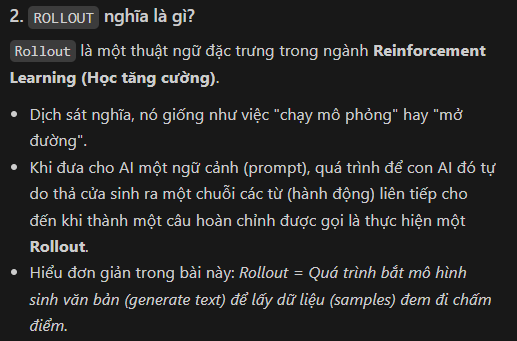

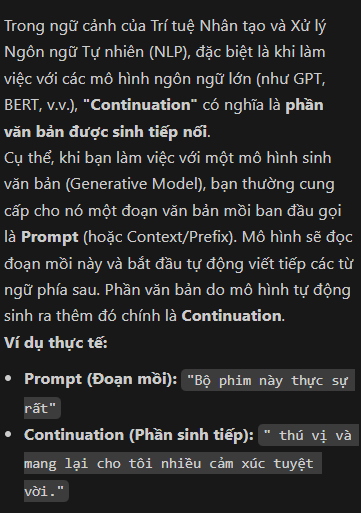

In [ ]:
import trl

# --- CHUẨN BỊ DATASET CHO RLHF ---
# Lọc các review dài (>200 ký tự) để có đủ context cho query
# Loại bỏ cột 'label' vì RLHF không cần nhãn

imdb_for_rlhf = imdb.filter(lambda row: len(row['text']) > 200, batched=False) #  batched=False nghĩa là lấy dừng dòng xử lý -> dùng cho hàm phức tạp nên chạy từng dòng, True thì chạy lists như dict, nên bật khi dataset lớn
imdb_for_rlhf = imdb_for_rlhf.remove_columns(['label'])
print(f"IMDB for RLHF: {len(imdb_for_rlhf)} samples (filtered from {len(imdb)})")

# Dùng LengthSampler có sẵn của thư viện TRL 0.8.6
sample_length = trl.core.LengthSampler(2, 8)

def select_query_and_tokenize(sample):
    """
    Trích xuất query (2-8 tokens đầu) từ mỗi sample.
    """
    # truncation=True để tránh cảnh báo sequence dài > 1024
    query_ids = main_tokenizer.encode(sample["text"], truncation=True)[: sample_length()]
    sample["query"] = main_tokenizer.decode(query_ids)  # query (string) là column bắt buộc
    sample["input_ids"] = query_ids  # lưu sẵn token IDs để tránh tokenize lại sau
    return sample

imdb_for_rlhf = imdb_for_rlhf.map(select_query_and_tokenize, batched=False)
imdb_for_rlhf.set_format(type="torch")

# Kiểm tra mẫu
print(f"\nSample query: '{imdb_for_rlhf[0]['query']}'")
print(f"Sample input_ids: {imdb_for_rlhf[0]['input_ids']}")


Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

IMDB for RLHF: 24895 samples (filtered from 25000)


Map:   0%|          | 0/24895 [00:00<?, ? examples/s]


Sample query: 'I rented'
Sample input_ids: tensor([   40, 26399])


In [16]:
# --- HÀM TÍNH REWARD CHO TEXT ---
from typing import List

def compute_reward(texts: List[str]) -> torch.Tensor:
    """
    Tính reward score cho một list các texts.
    TỐI ƯU HÓA SONG SONG GPU: Tokenize và tính toán trên GPU 1 (device_reward),
    sau đó chuyển kết quả trả về GPU 0 (device_main) để PPOTrainer xử lý.
    """
    inputs = reward_tokenizer(texts, truncation=True, padding=True, return_tensors='pt').to(device_reward)
    with torch.no_grad():
        rewards = reward_model(**inputs).logits[:, 0]
    return rewards.to(device_main)  # Chuyển output về GPU 0 của main_model

# Kiểm thử trên 2 samples có nhãn khác nhau từ IMDB
test_rewards = compute_reward([imdb[45]['text'], imdb[16000]['text']])
print(f"Reward sample 45  (label={imdb[45]['label']}): {test_rewards[0].item():.4f}")
print(f"Reward sample 16000 (label={imdb[16000]['label']}): {test_rewards[1].item():.4f}")


Reward sample 45  (label=0): -6.4346
Reward sample 16000 (label=1): 6.1641


### Cấu hình LoRA cho PPO Training

Thay vì train toàn bộ model (quá tốn kém), chúng ta sẽ train LoRA adapters.
LoRA (Low-Rank Adaptation) thêm các ma trận low-rank vào các layer linear,
chỉ train các ma trận này trong khi đóng băng toàn bộ weights gốc.

Chúng ta sẽ dùng `trl.AutoModelForCausalLMWithValueHead` -
một wrapper có thêm một "value head" (đầu ra giá trị) cần thiết cho PPO.
Value head này ước lượng giá trị (value function) của mỗi state,
dùng để tính advantage trong thuật toán PPO.

### PPOTrainer

TRL có một loại trainer đặc biệt giúp tối thiểu hóa PSO pseudo-loss.
Bạn có thể đọc thêm về trainer này [tại đây](https://huggingface.co/docs/trl/main/en/ppo_trainer).

**Cấu hình PPO:**
- `batch_size`: kích thước batch cho mỗi lần update
- `ppo_epochs`: số lần PPO update trên mỗi batch (PPO thực hiện nhiều update trên cùng 1 batch)
- `learning_rate`: learning rate cho optimizer
- `gradient_accumulation_steps`: tích lũy gradient qua nhiều batch nhỏ

In [29]:
import peft
import transformers
import trl

# --- CẤU HÌNH LORA ---
peft_config = peft.LoraConfig(
    task_type=peft.TaskType.CAUSAL_LM,  # Loại task: Causal Language Modeling (Sinh văn bản tiếp theo giống họ GPT)
    r=32,                               # Rank (hạng) của ma trận LoRA. Số r quyết định độ lớn của ma trận huấn luyện thêm. r lớn mô hình học chi tiết hơn nhưng tốn RAM hơn (thường dùng 8, 16, 32)
    lora_alpha=32,                      # Hệ số scaling (phóng to) trọng số LoRA. Thường được đặt bằng r hoặc 2*r. Trọng số thực tế = (alpha/r) * weight.
    lora_dropout=0.0,                   # Tỷ lệ Dropout áp dụng lên các trọng số LoRA để chống học vẹt (overfitting). Ở đây set 0.0 là tắt dropout.
    inference_mode=False                # False nghĩa là đang bật chế độ Training (cho phép tính đạo hàm và cập nhật trọng số).
)

# --- LOAD MAIN MODEL VỚI VALUE HEAD ---
main_tokenizer = transformers.AutoTokenizer.from_pretrained("lvwerra/gpt2-imdb")
main_tokenizer.pad_token = main_tokenizer.eos_token

# Dùng lại AutoModel chuẩn
main_model = trl.AutoModelForCausalLMWithValueHead.from_pretrained(
    "lvwerra/gpt2-imdb",
    peft_config=peft_config #gắn peft vào luôn 
).to(device_main)

# main_model.print_trainable_parameters()
main_model.pretrained_model.print_trainable_parameters()


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

trainable params: 1,179,648 || all params: 125,619,456 || trainable%: 0.9391


In [ ]:
# --- CẤU HÌNH PPO TRAINER ---
training_args = trl.PPOConfig(
    model_name=main_model.config._name_or_path,  # Tên model (gpt2-imdb)
    gradient_accumulation_steps=1,
    learning_rate=1.41e-5,
    batch_size=64, # batch_size bắt buộc chia hết cho mini_batch_size * gradient_accumulation_steps
    mini_batch_size=16,  # <-- THÊM DÒNG NÀY ĐỂ SỬA LỖI CHIA HẾT, giảm xuống cho phù hợp VRAM
    ppo_epochs=4,
)


# --- KHỞI TẠO PPO TRAINER ---
ppo_trainer = trl.PPOTrainer(
    training_args,
    model=main_model,
    tokenizer=main_tokenizer,
    dataset=imdb_for_rlhf,
    data_collator=lambda data: dict(
        (key, [d[key] for d in data]) for key in data[0]
    )
)

print("PPO Trainer initialized successfully!")


PPO Trainer initialized successfully!


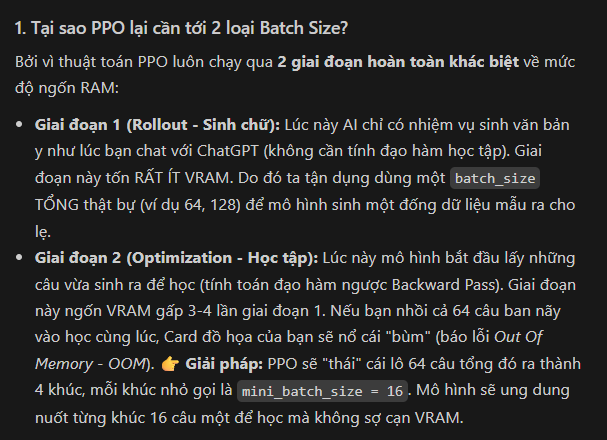

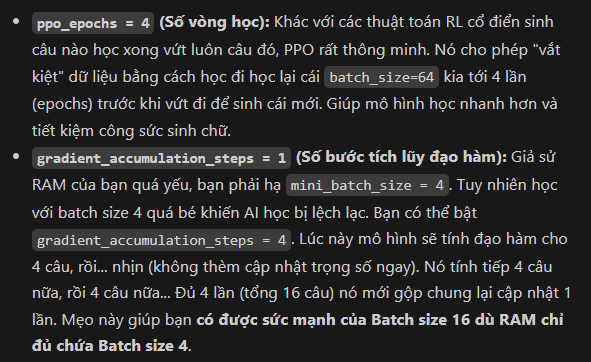

In [36]:
# --- PPO TRAINING LOOP ---
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

# (Các phần mã nguồn Rollout - Evaluation - Update tiếp theo giữ nguyên...)


In [ ]:
# --- PPO TRAINING LOOP ---
# Quy trình 3 bước: Rollout → Evaluation → Update

from tqdm.auto import tqdm

max_steps = 50  # Có thể không đủ cho một số task - hãy theo dõi learning curves

# Cấu hình generation
generation_kwargs = dict(
    min_length=-1,
    max_new_tokens=128,           # Số token mới tối đa được sinh
    do_sample=True,               # Sampling thay vì greedy decoding
    top_k=0,                      # Không giới hạn top-k
    top_p=1.0,                    # Nucleus sampling với top_p=1.0 = không giới hạn
    pad_token_id=main_tokenizer.eos_token_id  # Padding token cho generation
)

with tqdm(enumerate(ppo_trainer.dataloader), total=max_steps) as progressbar:
    # ppo_trainer.dataloader là dataloader thông thường của queries (không có RL magic gì đặc biệt)
    for epoch, batch in progressbar:
        if epoch >= max_steps:
            break

        # ===== GIAI ĐOẠN 1: ROLLOUT =====
        # Sinh continuation từ batch queries bằng main_model
        # Đầu vào: batch['input_ids'] - list of token ID sequences
        # Đầu ra: response_tensors - list of tensors (token IDs bao gồm cả query + continuation)
        response_tensors = ppo_trainer.generate(batch['input_ids'], **generation_kwargs)
        
        # Decode response tokens thành strings (vì reward model dùng tokenizer khác)
        batch["response"] = [
            main_tokenizer.decode(response.squeeze()) for response in response_tensors
        ]
        # Lưu ý: response_tensors đã chứa cả query tokens, không cần thêm query thủ công.

        # ===== GIAI ĐOẠN 2: EVALUATION =====
        # Tính reward cho các responses vừa sinh
        rewards = compute_reward(batch['response'])

        # ===== GIAI ĐOẠN 3: UPDATE =====
        # Cập nhật model bằng PPO
        # step() nhận:
        #   - batch['input_ids']: queries (token IDs) là prompt ban đầu
        #   - response_tensors: responses (token IDs) là văn bản được sinh rollout 
        #   - list(rewards.split(1)): rewards cho từng response (chia thành list of 1-element tensors)
        stats = ppo_trainer.step(batch['input_ids'], response_tensors, list(rewards.split(1)))
        stats['rewards/mean'] = rewards.mean().item() # tự tính mean

        # ===== LOGGING =====
        print("-" * 30, 'STEP', epoch, '-' * 30)
        print(f'rewards/mean:\t{stats["rewards/mean"]:.9f}\t<---- reward trung bình batch (cao hơn = tốt hơn, nhiễu)')
        print(f'ppo/returns/mean:\t{stats["ppo/returns/mean"]:.9f}\t<---- discounted reward trung bình model ước lượng')
        print(f'objective/kl:\t{stats["objective/kl"]:.9f}\t<---- khoảng cách KL từ model gốc (regularizer)')
        print()

        # Log stats
        ppo_trainer.log_stats(stats, batch, list(rewards.split(1)))


  0%|          | 0/50 [00:00<?, ?it/s]

------------------------------ STEP 0 ------------------------------
rewards/mean:	-0.391867727	<---- reward trung bình batch (cao hơn = tốt hơn, nhiễu)
ppo/returns/mean:	-0.034478456	<---- discounted reward trung bình model ước lượng
objective/kl:	0.000000000	<---- khoảng cách KL từ model gốc (regularizer)

------------------------------ STEP 1 ------------------------------
rewards/mean:	0.088452786	<---- reward trung bình batch (cao hơn = tốt hơn, nhiễu)
ppo/returns/mean:	-0.033159286	<---- discounted reward trung bình model ước lượng
objective/kl:	0.025112126	<---- khoảng cách KL từ model gốc (regularizer)

------------------------------ STEP 2 ------------------------------
rewards/mean:	-0.059165597	<---- reward trung bình batch (cao hơn = tốt hơn, nhiễu)
ppo/returns/mean:	-0.027245518	<---- discounted reward trung bình model ước lượng
objective/kl:	0.042905763	<---- khoảng cách KL từ model gốc (regularizer)

------------------------------ STEP 3 ------------------------------
re

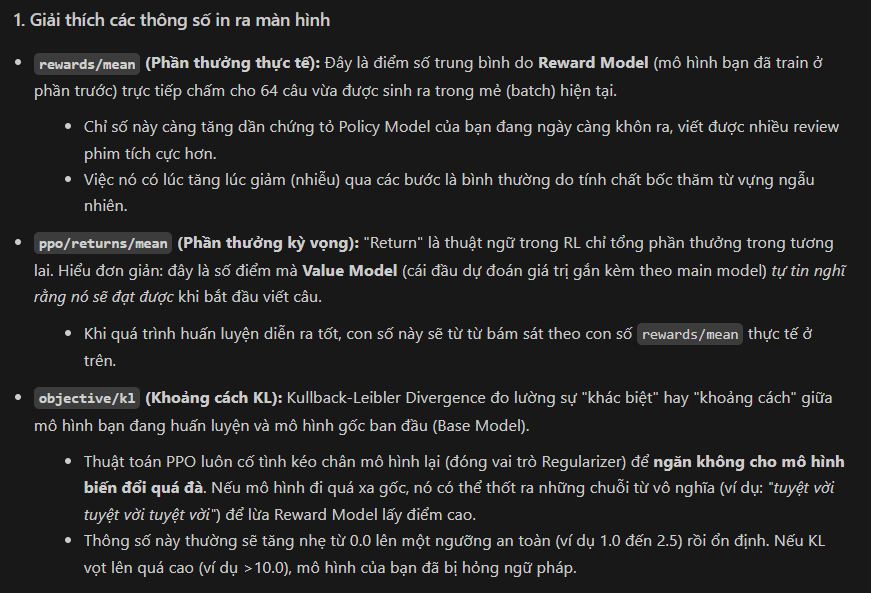

In [40]:
import os

# Tạo thư mục trước nếu chưa tồn tại
os.makedirs("gpt2-imdb-ppo-lora", exist_ok=True)

# Lưu weights của LoRA adapter và tokenizer
main_model.save_pretrained("gpt2-imdb-ppo-lora")
main_tokenizer.save_pretrained("gpt2-imdb-ppo-lora")

print("Đã tạo thư mục và lưu mô hình PPO thành công vào 'gpt2-imdb-ppo-lora'!")


Đã tạo thư mục và lưu mô hình PPO thành công vào 'gpt2-imdb-ppo-lora'!


In [41]:
import shutil

# Nén thư mục 'gpt2-imdb-ppo-lora' thành file 'gpt2-imdb-ppo-lora.zip'
shutil.make_archive("gpt2-imdb-ppo-lora", "zip", "gpt2-imdb-ppo-lora")

print("Đã nén thành công thành file 'gpt2-imdb-ppo-lora.zip' để tải xuống!")


Đã nén thành công thành file 'gpt2-imdb-ppo-lora.zip' để tải xuống!


In [39]:
# --- SINH THỬ REVIEW TỪ MÔ HÌNH SAU KHI TRAIN RLHF ---
prompts = [
    "This movie was",
    "The acting is",
    "I felt that the film"
]

generation_kwargs = dict(
    min_length=-1,
    max_new_tokens=40,
    do_sample=True,
    top_k=0,
    top_p=1.0,
    pad_token_id=main_tokenizer.eos_token_id
)

print("=== CÁC REVIEW ĐƯỢC SINH RA BỞI MÔ HÌNH PPO FINETUNED ===")
for prompt in prompts:
    inputs = main_tokenizer(prompt, return_tensors="pt").to(device_main)
    # Tắt adapter để xem mô hình cũ sinh gì (tùy chọn) hoặc chạy thẳng mô hình hiện tại
    outputs = main_model.generate(**inputs, **generation_kwargs)
    generated_text = main_tokenizer.decode(outputs[0], skip_special_tokens=True)
    print(f"Prompt: '{prompt}'")
    print(f"Generated: '{generated_text}'")
    print("-" * 50)


=== CÁC REVIEW ĐƯỢC SINH RA BỞI MÔ HÌNH PPO FINETUNED ===
Prompt: 'This movie was'
Generated: 'This movie was enjoyable and I enjoyed seeing it again. I recommend it'
--------------------------------------------------
Prompt: 'The acting is'
Generated: 'The acting is simple. The leading man, Robert De Niro, is over-acting and everything is believable. There is not enough on screen to be loved. Also, Parks, as an ensemble, is excellent'
--------------------------------------------------
Prompt: 'I felt that the film'
Generated: 'I felt that the film suggesting that BREATHFAST, like BEYOND BASTARD, was an excellent choice for director Godfrey Lamb, your director of "feminist films," which is always the perfect and best'
--------------------------------------------------


---
## [Optional] Bonus Assignment: RL Fine-tuning in the Wild

Sử dụng RLHF pipeline để train một model cho reward mà bạn chọn.
Dưới đây là một số lựa chọn:

### A. Toxicity Fine-tuning
Train model để trở nên ít (hoặc nhiều!) toxic hơn.
Sử dụng dữ liệu từ [jigsaw toxic comments](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge)
và [lmsys/toxic-chat](https://huggingface.co/datasets/lmsys/toxic-chat).

### B. Actual Human Feedback
Sử dụng dataset có pairwise human feedback:
- [anthropic's hh-rlhf](https://huggingface.co/datasets/Anthropic/hh-rlhf)
- [OpenAssistant dataset](https://huggingface.co/datasets/OpenAssistant/oasst1)

### C. Controlled Generation
Định nghĩa reward function như:
- Độ dài văn bản (dài hơn hoặc ngắn hơn)
- Số lần model sử dụng từ cụ thể (vd: "sorry", "apologize")

---

### General Tips & Tricks

1. Trong PPO stage, reward model phải ở eval mode (tắt dropout)
2. Đảm bảo max_length và max_new_tokens đủ cho dataset của bạn
3. Khi nghi ngờ, hãy xem dữ liệu thủ công hoặc kiểm tra model trên vài samples

**Quy trình kiểm tra:**
1. Sau khi tạo pairwise dataset: kiểm tra một vài cặp, giải mã và đảm bảo bạn hiểu tại sao sample này được chọn
2. Sau khi train reward model: đo accuracy của model
3. Sau khi train main model với RL: sinh examples và kiểm tra chất lượng

---

### Bonus Assignment Stages

#### Stage 1: Reward Model
- Xây dựng dataset cho reward model
- Train reward model và đánh giá trên test set

#### Stage 2: RL Fine-tuning
- Chọn language model để fine-tune
- Chạy PPO training
- Cung cấp ít nhất 20 side-by-side examples (fine-tuned vs original)

## Phụ lục bổ sung: Tại sao lại dùng RLHF thay vì chỉ Fine-tune trên tập dữ liệu toàn câu review tốt?

Một câu hỏi rất tự nhiên là: *"Nếu muốn mô hình sinh ra review tích cực, tại sao không lấy một tập dữ liệu chỉ chứa 100% review tốt và cho mô hình học thuộc (Supervised Fine-Tuning - SFT) bằng Cross-Entropy loss thông thường, mà lại phải dùng Reinforcement Learning (RL) rườm rà?"*

Dưới đây là so sánh ưu - nhược điểm của 2 phương pháp:

### 1. Phương pháp Supervised Fine-Tuning (SFT) trên tập dữ liệu tốt
*Bản chất: "Nhìn văn bản mẫu tốt và học thuộc" (Behavior Cloning).*

**Ưu điểm:**
- **Đơn giản & Dễ triển khai:** Thuật toán quen thuộc, quá trình hội tụ (training) rất ổn định.

**Nhược điểm:**
- **Nút thắt về dữ liệu (Data bottleneck):** Rất tốn kém để tạo ra hàng vạn ví dụ hoàn hảo. Hơn nữa, những câu này chỉ là một góc nhỏ trong ngôn ngữ.
- **Không biết thế nào là sai (Exposure Bias):** Mô hình chỉ được dạy *"hãy đi theo con đường này"*, nhưng không hề biết *"con đường kia là hố sâu, hãy tránh ra"*. Trong thực tế, nếu mô hình lỡ sinh ra một từ hơi tiêu cực, nó sẽ luống cuống không biết cách quay lại quỹ đạo tích cực vì chưa bao giờ nhìn thấy và bị phạt vì lỗi đó.
- **Mất tính đa dạng (Diversity):** Mô hình thường có xu hướng chỉ lặp lại một vài cấu trúc câu khen ngợi quen thuộc có trong tập huấn luyện.

---

### 2. Phương pháp Reinforcement Learning (RLHF / PPO)
*Bản chất: "Tự do làm bài, nộp bài, và học dựa trên điểm số (Reward)".*

**Ưu điểm:**
- **Cho phép mô hình tự do khám phá:** Mô hình không bị gò bó phải bắt chước chính xác một câu cụ thể nào. Nó sinh ra câu bất kỳ, Reward Model chấm điểm, và nếu điểm cao, nó tự nhận ra: *"À, cách hành văn này cũng tốt nè"*.
- **Hiểu rõ ranh giới Tốt/Xấu:** Bằng việc so sánh (Chosen vs Rejected) lúc luyện Reward Model, hệ thống giúp Policy Model biết cách né tránh những từ ngữ mang tính tiêu cực.
- **Phù hợp với những thứ "Chủ quan":** Văn bản thế nào là hay, là lịch sự, là vô hại không thể có đáp án 100% chính xác tuyệt đối như bài toán phân loại chó mèo. Dùng điểm số (Reward) mềm dẻo hơn rất nhiều so với dùng Hard Label.

**Nhược điểm:**
- **Cực kỳ phức tạp và tốn kém phần cứng:** Để chạy RLHF, bạn phải duy trì cùng lúc nhiều mô hình trên RAM (Policy Model, Reference/Base Model để chặn mô hình khỏi việc sinh text ngớ ngẩn, Reward Model, Value Model).
- **Thiếu ổn định và Reward Hacking:** RL(PPO) vô cùng nhạy cảm với các tham số (learning rate, KL penalty). Đặc biệt, mô hình rất hay mắc bệnh "Hack điểm" (Reward Hacking) - ví dụ: tìm ra kẽ hở của Reward Model bằng cách lặp đi lặp lại từ *"tuyệt vời, tuyệt vời, tuyệt vời"* để lấy điểm tối đa mà không tạo ra một câu có nghĩa.